In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = pd.read_csv('all_drones_position_20250404_134911.csv')

# drop the unnecessary columns qx qy qz qw
data = data.drop(columns=['qx', 'qy', 'qz', 'qw'])

# Convert timestamp to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')
# Set the timestamp as the index
data.set_index('timestamp', inplace=True)

# nowb i a new dataframe with the position of each drone as their own column so if there are 3 drones, the columns will be:
# drone1, drone2, drone3
drones = data['drone'].unique()
#then the xy coordinates of each drone will be in the drone columns with the values in the columns beinng the x y and z coordinates
position_data = pd.DataFrame(index=data.index)
for drone in drones:
    drone_data = data[data['drone'] == drone]
    position_data[f'{drone}_x'] = drone_data['x']
    position_data[f'{drone}_y'] = drone_data['y']
    position_data[f'{drone}_z'] = drone_data['z']   


# another column that is the distance between each drone and the first drone
for drone in drones[1:]:
    position_data[f'{drone}_distance_from_{drones[0]}'] = np.sqrt(
        (position_data[f'{drones[0]}_x'] - position_data[f'{drone}_x']) ** 2 +
        (position_data[f'{drones[0]}_y'] - position_data[f'{drone}_y']) ** 2 +
        (position_data[f'{drones[0]}_z'] - position_data[f'{drone}_z']) ** 2
    )







/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 2.2.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [7]:
import pandas as pd
import numpy as np
from itertools import combinations

def calculate_collision_rate(csv_file, collision_threshold=0.1):
    """
    Calculate collision rate for a drone session.
    
    Parameters:
    csv_file (str): Path to CSV file
    collision_threshold (float): Distance threshold for collision (meters)
    
    Returns:
    dict: Collision statistics
    """
    
    # Load data
    data = pd.read_csv(csv_file)
    
    # Use only needed columns
    data = data[['relative_time', 'x', 'y', 'z', 'drone_id']].dropna()
    
    collisions = 0
    total_checks = 0
    
    # Check each timestamp
    for time in data['relative_time'].unique():
        # Get all drones at this timestamp
        drones_at_time = data[data['relative_time'] == time]
        
        # Check all drone pairs
        drone_list = drones_at_time.to_dict('records')
        
        for drone1, drone2 in combinations(drone_list, 2):
            # Calculate 3D distance
            distance = np.sqrt(
                (drone1['x'] - drone2['x'])**2 + 
                (drone1['y'] - drone2['y'])**2 + 
                (drone1['z'] - drone2['z'])**2
            )
            
            total_checks += 1
            
            # Check if collision
            if distance <= collision_threshold:
                collisions += 1
    
    # Calculate rate
    collision_rate = (collisions / total_checks * 100) if total_checks > 0 else 0
    
    return {
        'session_file': csv_file,
        'total_collisions': collisions,
        'total_checks': total_checks,
        'collision_rate_percent': collision_rate,
        'num_drones': data['drone_id'].nunique(),
        'duration_seconds': data['relative_time'].max() - data['relative_time'].min()
    }

# Example usage for single session
csv_file = 'all_drones_position_20250404_134911.csv'
result = calculate_collision_rate(csv_file)

print(f"Session: {result['session_file']}")
print(f"Collisions: {result['total_collisions']}")
print(f"Collision Rate: {result['collision_rate_percent']:.4f}%")
print(f"Drones: {result['num_drones']}")
print(f"Duration: {result['duration_seconds']:.1f} seconds")

Session: all_drones_position_20250404_134911.csv
Collisions: 11
Collision Rate: 0.7079%
Drones: 3
Duration: 103.4 seconds


In [ ]:
import pandas as pd
import numpy as np
import os
from itertools import combinations
from datetime import datetime

def calculate_collision_and_metrics(csv_file, collision_threshold=0.1, near_miss_threshold=0.61):
    """
    Calculate collision rate, near-miss rate, and average inter-drone distance.
    
    Parameters:
    csv_file (str): Path to CSV file
    collision_threshold (float): Distance threshold for collision (meters)
    near_miss_threshold (float): Distance threshold for near-miss (meters)
    
    Returns:
    dict: Comprehensive statistics
    """
    # Load data
    data = pd.read_csv(csv_file)
    
    # Use only needed columns
    data = data[['relative_time', 'x', 'y', 'z', 'drone_id']].dropna()
    
    collisions = 0
    near_misses = 0
    total_checks = 0
    all_distances = []
    
    # Check each timestamp
    for time in data['relative_time'].unique():
        # Get all drones at this timestamp
        drones_at_time = data[data['relative_time'] == time]
        
        # Check all drone pairs
        drone_list = drones_at_time.to_dict('records')
        
        for drone1, drone2 in combinations(drone_list, 2):
            # Calculate 3D distance of drones
            distance = np.sqrt(
                (drone1['x'] - drone2['x'])**2 +
                (drone1['y'] - drone2['y'])**2 +
                (drone1['z'] - drone2['z'])**2
            )
            
            total_checks += 1
            all_distances.append(distance)
            
            # Check if collision
            if distance <= collision_threshold:
                collisions += 1
            # Check if near-miss (between collision and near-miss threshold)
            elif distance <= near_miss_threshold:
                near_misses += 1
    
    # Calculate statistics
    collision_rate = (collisions / total_checks * 100) if total_checks > 0 else 0
    near_miss_rate = (near_misses / total_checks * 100) if total_checks > 0 else 0
    avg_distance = np.mean(all_distances) if all_distances else 0
    min_distance = np.min(all_distances) if all_distances else 0
    
    return {
        'session_file': csv_file,
        'total_collisions': collisions,
        'total_near_misses': near_misses,
        'total_checks': total_checks,
        'collision_rate_percent': collision_rate,
        'near_miss_rate_percent': near_miss_rate,
        'average_inter_drone_distance': avg_distance,
        'minimum_distance': min_distance,
        'num_drones': data['drone_id'].nunique(),
        'duration_seconds': data['relative_time'].max() - data['relative_time'].min()
    }

def get_file_info(filename):
    """Extract date and time from filename for sorting."""
    try:
        # Try to extract timestamp from filename
        # Assuming format like: all_drn_position_test_4_4_20250804_160810.csv
        parts = filename.split('_')
        if len(parts) >= 2:
            date_part = parts[-2]  # Date part (YYYYMMDD)
            time_part = parts[-1].replace('.csv', '')  # Time part (HHMMSS)
            
            # Parse date and time
            year = int(date_part[:4])
            month = int(date_part[4:6])
            day = int(date_part[6:8])
            hour = int(time_part[:2])
            minute = int(time_part[2:4])
            second = int(time_part[4:6])
            
            return datetime(year, month, day, hour, minute, second)
    except:
        pass
    
    # Fallback to file modification time
    return datetime.fromtimestamp(os.path.getmtime(filename))

def select_csv_file():
    """
    Show available CSV files in current directory sorted by date/time.
    
    Returns:
    str: Selected CSV file name
    """
    # Get all CSV files in current directory
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
    
    if not csv_files:
        print("No CSV files found in current directory!")
        return None
    
    # Sort files by date/time
    csv_files_with_time = [(f, get_file_info(f)) for f in csv_files]
    csv_files_sorted = sorted(csv_files_with_time, key=lambda x: x[1], reverse=True)
    
    print("Available CSV files (sorted by date, newest first):")
    print("-" * 80)
    
    for i, (file, timestamp) in enumerate(csv_files_sorted, 1):
        # Get file size
        size_mb = os.path.getsize(file) / (1024 * 1024)
        print(f"{i:3d}. {file:<50} [{timestamp.strftime('%Y-%m-%d %H:%M:%S')}] ({size_mb:.1f} MB)")
    
    print("-" * 80)
    
    while True:
        try:
            choice = int(input(f"\nSelect file (1-{len(csv_files)}): "))
            if 1 <= choice <= len(csv_files):
                return csv_files_sorted[choice - 1][0]
            else:
                print(f"Please enter a number between 1 and {len(csv_files)}")
        except ValueError:
            print("Please enter a valid number")

def format_results(result):
    """Format and display results in a simple manner."""
    print("\n" + "="*50)
    print("COLLISION ANALYSIS RESULTS")
    print("="*50)
    print(f"Session: {result['session_file']}")
    print(f"Collisions: {result['total_collisions']}")
    print(f"Collision Rate: {result['collision_rate_percent']:.4f}%")
    print(f"Near-Misses: {result['total_near_misses']}")
    print(f"Near-Miss Rate: {result['near_miss_rate_percent']:.4f}%")
    print(f"Avg Inter-Drone Distance: {result['average_inter_drone_distance']:.3f} meters")
    print(f"Drones: {result['num_drones']}")
    print(f"Duration: {result['duration_seconds']:.1f} seconds")
    print(f"Total checks: {result['total_checks']:,}")

# Main execution
if __name__ == "__main__":
    # Select CSV file
    csv_file = select_csv_file()
    
    if csv_file:
        print(f"\nAnalyzing: {csv_file}")
        
        # Calculate collision rate and metrics
        result = calculate_collision_and_metrics(csv_file)
        
        # Display formatted results
        format_results(result)
    else:
        print("No file selected. Exiting.")

Available CSV files:
1. all_drones_position_20250328_134651.csv
2. drone1_test_20250804_230057.csv
3. all_drn_position_test_320250730_145207.csv
4. all_drn_position_test_4_4_20250803_001349.csv
5. all_drn_position_test_4_4_20250804_223352.csv
6. drone3_test_20250804_230923.csv
7. all_drn_position_test_2_4_20250730_183756.csv
8. drone2_test_20250804_230922.csv
9. all_drn_position_test_3_1_20250731_170841.csv
10. drone1_test_20250804_230923.csv
11. drone2_test_20250804_230057.csv
12. all_drn_position_test_3_1_20250731_235901.csv
13. secnario1.csv
14. all_drn_position_test_2_4_20250730_180617.csv
15. all_drones_position_20250328_132241.csv
16. all_drn_position_test_2_4_20250731_145323.csv
17. all_drones_position_20250729_195721.csv
18. all_drn_position_test_3_1_20250802_160554.csv
19. all_drn_position_test_3_1_20250802_163459.csv
20. all_drn_position_test_4_4_20250804_133920.csv
21. all_drones_position_20250328_071708.csv
22. all_drn_position_test_20250729_231449.csv
23. drone2_test_20250

In [6]:
import warnings

warnings.filterwarnings("error")
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from itertools import combinations

# Visualize a csv file contain the collision analysis results
def visualize_collision_analysis(csv_file):
    """
    Visualize collision analysis results from a CSV file.
    
    Parameters:
    csv_file (str): Path to CSV file
    """
    
    # Load data
    data = pd.read_csv(csv_file)
    
    # Use only needed columns
    data = data[['Test', 'collisions', 'collision_rate (%)', 'number_of_drones', 'duration (s)', 'total_checks']].dropna()
    
    data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your CSV
csv_file = 'scenario_2.csv'
df = pd.read_csv(csv_file)

df




,Test,collisions,collision_rate (%),number_of_drones,duration (s),total_checks
0,test1,1,50.0000,2,215.8,2
1,test2,9,0.8637,2,208.2,1042
2,test3,37,3.5514,2,213.8,1070
3,test4,0,0.0000,2,206.6,1034
4,test5,0,0.0000,2,218.4,1
5,test6,1,20.0000,2,209.2,5
6,test7,12,1.1617,2,206.4,1033
7,test8,16,1.5826,2,202.0,1011
8,test9,8,0.7805,2,204.8,1025
9,test10,11,1.0649,2,206.4,1033


Collision Rate Statistics by Drone Count:
 number_of_drones  mean_rate  median_rate  std_rate  count
                2    1.29552      0.90715  2.166764     10
                3    3.16810      1.54400  4.199882     10
                4    8.69509      6.65890  6.550974     10

Average Drone Distance Statistics by Drone Count:
 number_of_drones  dist_mean_rate  median_rate  std_rate  count
                2         3.04540       3.4675  2.175597     10
                3         4.17758       5.2270  2.649715     10
                4         3.60270       4.1095  1.813076     10

Near Misses Rate Statistics by Drone Count:
 number_of_drones  near_miss_mean_rate  near_miss_median_rate  near_miss_std_rate  count
                2             22.01184                7.25285           37.473573     10
                3             34.74244               28.53445           30.585242     10
                4             39.11155               31.98590           17.348597     10


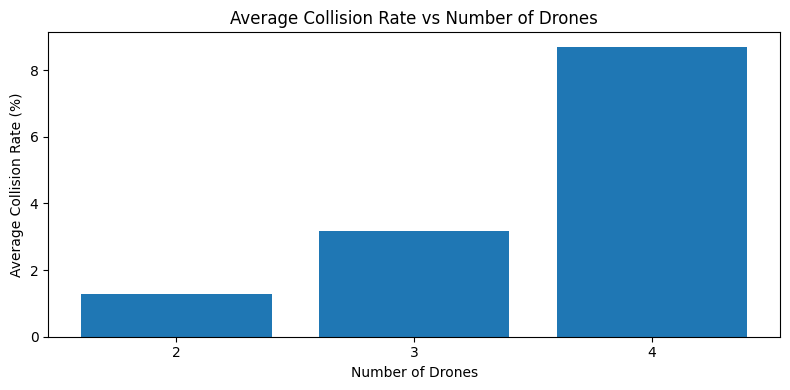

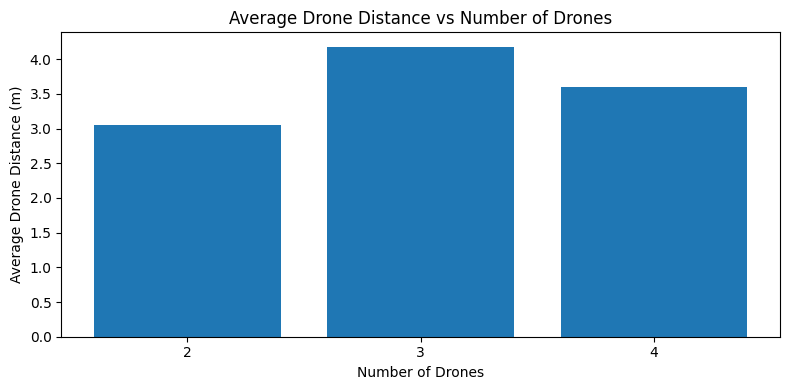

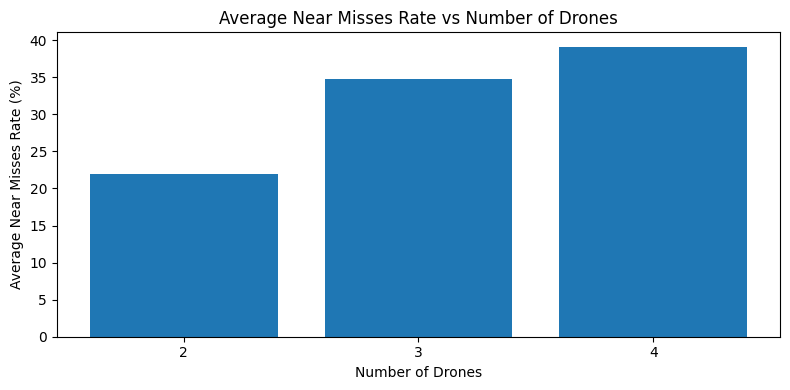


Pearson correlation between drone count and collision rate: 0.557


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your CSV
csv_file = 'scenario_3.csv'
df = pd.read_csv(csv_file)

# 2. Keep only the relevant columns and drop missing data
df = df[['number_of_drones', 'collision_rate(%)','near_misses_rate(%)','avg_drone_dist(m)']].dropna()

# 3. Compute grouping statistics
stats = df.groupby('number_of_drones')['collision_rate(%)'].agg(
    mean_rate='mean',
    median_rate='median',
    std_rate='std',
    count='count'
).reset_index()

# compute the average drone distance
dist_stats = df.groupby('number_of_drones')['avg_drone_dist(m)'].agg(
    dist_mean_rate='mean',
    median_rate='median',
    std_rate='std',
    count='count'
).reset_index()

# compute the near misses rate
near_miss_stats = df.groupby('number_of_drones')['near_misses_rate(%)'].agg(
    near_miss_mean_rate='mean',
    near_miss_median_rate='median',
    near_miss_std_rate='std',
    count='count'
).reset_index()

print("Collision Rate Statistics by Drone Count:")
print(stats.to_string(index=False))

print("\nAverage Drone Distance Statistics by Drone Count:")
print(dist_stats.to_string(index=False))

print("\nNear Misses Rate Statistics by Drone Count:")
print(near_miss_stats.to_string(index=False))

# 4. Bar chart of the mean collision rate
plt.figure(figsize=(8, 4))
plt.bar(stats['number_of_drones'], stats['mean_rate'])
plt.title('Average Collision Rate vs Number of Drones')
plt.xlabel('Number of Drones')
plt.ylabel('Average Collision Rate (%)')
plt.xticks(stats['number_of_drones'])
plt.tight_layout()
plt.show()

# 5. Bar chart of the average drone distance
plt.figure(figsize=(8, 4))
plt.bar(stats['number_of_drones'], dist_stats['dist_mean_rate'])
plt.title('Average Drone Distance vs Number of Drones')
plt.xlabel('Number of Drones')
plt.ylabel('Average Drone Distance (m)')
plt.xticks(stats['number_of_drones'])
plt.tight_layout()
plt.show()

# 5. Bar chart of the near misses rate
plt.figure(figsize=(8, 4))
plt.bar(near_miss_stats['number_of_drones'], near_miss_stats['near_miss_mean_rate'])
plt.title('Average Near Misses Rate vs Number of Drones')
plt.xlabel('Number of Drones')
plt.ylabel('Average Near Misses Rate (%)')
plt.xticks(near_miss_stats['number_of_drones'])
plt.tight_layout()
plt.show()

# 6. Additional metric: correlation
corr = df['number_of_drones'].corr(df['collision_rate(%)'])
print(f"\nPearson correlation between drone count and collision rate: {corr:.3f}")


In [5]:
import pandas as pd
import numpy as np
import os
from itertools import combinations
from datetime import datetime

def calculate_collision_and_metrics(csv_file, collision_threshold=0.1, near_miss_threshold=0.61):
    """
    Calculate collision rate, near-miss rate, and average inter-drone distance.
    
    Parameters:
    csv_file (str): Path to CSV file
    collision_threshold (float): Distance threshold for collision (meters)
    near_miss_threshold (float): Distance threshold for near-miss (meters)
    
    Returns:
    dict: Comprehensive statistics
    """
    # Load data
    data = pd.read_csv(csv_file)
    
    # Use only needed columns
    data = data[['relative_time', 'x', 'y', 'z', 'drone_id']].dropna()
    
    collisions = 0
    near_misses = 0
    total_checks = 0
    all_distances = []
    
    # Check each timestamp
    for time in data['relative_time'].unique():
        # Get all drones at this timestamp
        drones_at_time = data[data['relative_time'] == time]
        
        # Check all drone pairs
        drone_list = drones_at_time.to_dict('records')
        
        for drone1, drone2 in combinations(drone_list, 2):
            # Calculate 3D distance of drones
            distance = np.sqrt(
                (drone1['x'] - drone2['x'])**2 +
                (drone1['y'] - drone2['y'])**2 +
                (drone1['z'] - drone2['z'])**2
            )
            
            total_checks += 1
            all_distances.append(distance)
            
            # Check if collision
            if distance <= collision_threshold:
                collisions += 1
            # Check if near-miss (between collision and near-miss threshold)
            elif distance <= near_miss_threshold:
                near_misses += 1
    
    # Calculate statistics
    collision_rate = (collisions / total_checks * 100) if total_checks > 0 else 0
    near_miss_rate = (near_misses / total_checks * 100) if total_checks > 0 else 0
    avg_distance = np.mean(all_distances) if all_distances else 0
    min_distance = np.min(all_distances) if all_distances else 0
    
    return {
        'session_file': csv_file,
        'total_collisions': collisions,
        'total_near_misses': near_misses,
        'total_checks': total_checks,
        'collision_rate_percent': collision_rate,
        'near_miss_rate_percent': near_miss_rate,
        'average_inter_drone_distance': avg_distance,
        'minimum_distance': min_distance,
        'num_drones': data['drone_id'].nunique(),
        'duration_seconds': data['relative_time'].max() - data['relative_time'].min()
    }

def get_file_info(filename):
    """Extract date and time from filename for sorting."""
    try:
        # Try to extract timestamp from filename
        # Assuming format like: all_drn_position_test_4_4_20250804_160810.csv
        parts = filename.split('_')
        if len(parts) >= 2:
            date_part = parts[-2]  # Date part (YYYYMMDD)
            time_part = parts[-1].replace('.csv', '')  # Time part (HHMMSS)
            
            # Parse date and time
            year = int(date_part[:4])
            month = int(date_part[4:6])
            day = int(date_part[6:8])
            hour = int(time_part[:2])
            minute = int(time_part[2:4])
            second = int(time_part[4:6])
            
            return datetime(year, month, day, hour, minute, second)
    except:
        pass
    
    # Fallback to file modification time
    return datetime.fromtimestamp(os.path.getmtime(filename))

def select_csv_file():
    """
    Show available CSV files in current directory sorted by filename.
    
    Returns:
    str: Selected CSV file name
    """
    # Get all CSV files in current directory
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
    
    if not csv_files:
        print("No CSV files found in current directory!")
        return None
    
    # Sort files alphabetically by filename
    csv_files.sort()
    
    print("Available CSV files (sorted alphabetically):")
    print("-" * 80)
    
    for i, file in enumerate(csv_files, 1):
        # Get file size
        size_mb = os.path.getsize(file) / (1024 * 1024)
        # Get file timestamp
        timestamp = get_file_info(file)
        print(f"{i:3d}. {file:<50} [{timestamp.strftime('%Y-%m-%d %H:%M:%S')}] ({size_mb:.1f} MB)")
    
    print("-" * 80)
    
    while True:
        try:
            choice = int(input(f"\nSelect file (1-{len(csv_files)}): "))
            if 1 <= choice <= len(csv_files):
                return csv_files[choice - 1]
            else:
                print(f"Please enter a number between 1 and {len(csv_files)}")
        except ValueError:
            print("Please enter a valid number")

def format_results(result):
    """Format and display results in a simple manner."""
    print("\n" + "="*50)
    print("COLLISION ANALYSIS RESULTS")
    print("="*50)
    print(f"Session: {result['session_file']}")
    print(f"Collisions: {result['total_collisions']}")
    print(f"Collision Rate: {result['collision_rate_percent']:.4f}%")
    print(f"Near-Misses: {result['total_near_misses']}")
    print(f"Near-Miss Rate: {result['near_miss_rate_percent']:.4f}%")
    print(f"Avg Inter-Drone Distance: {result['average_inter_drone_distance']:.3f} meters")
    print(f"Drones: {result['num_drones']}")
    print(f"Duration: {result['duration_seconds']:.1f} seconds")
    print(f"Total checks: {result['total_checks']:,}")

# Main execution
if __name__ == "__main__":
    # Select CSV file
    csv_file = select_csv_file()
    
    if csv_file:
        print(f"\nAnalyzing: {csv_file}")
        
        # Calculate collision rate and metrics
        result = calculate_collision_and_metrics(csv_file)
        
        # Display formatted results
        format_results(result)
    else:
        print("No file selected. Exiting.")

Available CSV files (sorted alphabetically):
--------------------------------------------------------------------------------
  1. all_drn_position_2_drn_test_20250729_231449.csv    [2025-07-29 23:14:49] (0.4 MB)
  2. all_drn_position_2_drn_test_20250729_232441.csv    [2025-07-29 23:24:41] (0.4 MB)
  3. all_drn_position_2_drn_test_320250730_145207.csv   [2025-07-30 14:52:07] (0.4 MB)
  4. all_drn_position_test_2_4_20250730_180617.csv      [2025-07-30 18:06:17] (0.4 MB)
  5. all_drn_position_test_2_4_20250730_180618.csv      [2025-07-30 18:06:18] (0.4 MB)
  6. all_drn_position_test_2_4_20250730_183756.csv      [2025-07-30 18:37:56] (0.4 MB)
  7. all_drn_position_test_2_4_20250730_204933.csv      [2025-07-30 20:49:33] (0.4 MB)
  8. all_drn_position_test_2_4_20250730_220903.csv      [2025-07-30 22:09:03] (0.4 MB)
  9. all_drn_position_test_2_4_20250730_222606.csv      [2025-07-30 22:26:06] (0.4 MB)
 10. all_drn_position_test_2_4_20250730_230557.csv      [2025-07-30 23:05:57] (0.4 MB)
 11.